In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Customer Churn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Replacing blank with 0 as tenure is 0 and Total Charges are recorded

In [4]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### To check any NULL values are in there or not

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


#### Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

#### Check duplicates are present in unique columns

In [9]:
df["customerID"].duplicated().sum()

np.int64(0)

In [10]:
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "No"
        
df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

#### Convert SeniorCitizen  Values 1 as "YES" & 0 as "NO"

#### How Many Customer Churn Out Or Not

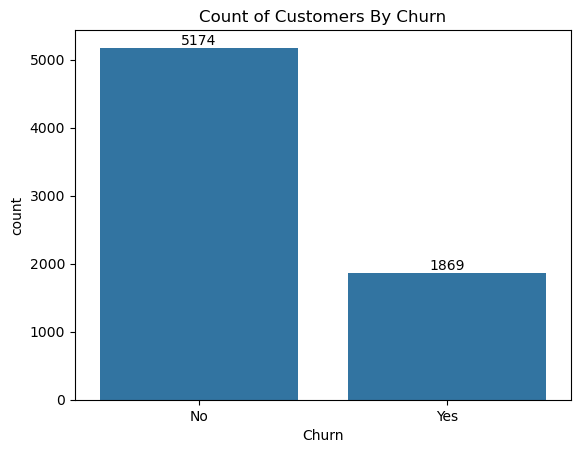

In [11]:
ax = sns.countplot(x = 'Churn' , data = df)


ax.bar_label(ax.containers[0])
plt.title("Count of Customers By Churn")
plt.show()

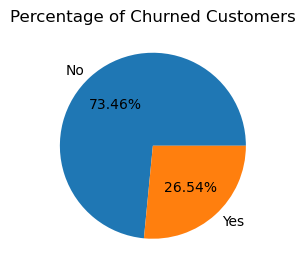

In [12]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customers")
plt.show()




#### From the given Pie Chart We Can Conclude that 26.54% of our Customers have Churned out. 
***Now let's explore the reason behind it.**

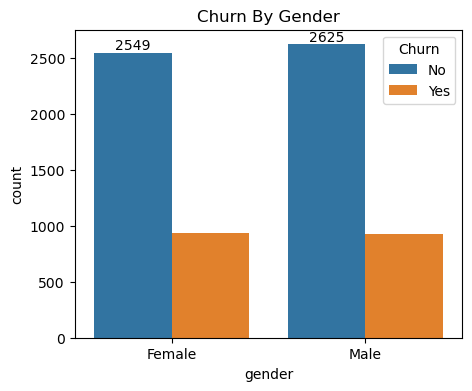

In [13]:
plt.figure(figsize = (5,4))
ax = sns.countplot(x="gender", data = df , hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Churn By Gender")
plt.show()

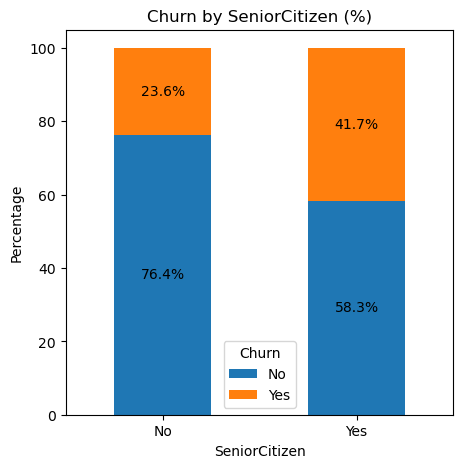

In [14]:
total_counts = df.groupby('SeniorCitizen')['Churn'] \
                 .value_counts(normalize=True) \
                 .unstack() * 100

# Step 2: Plot
fig, ax = plt.subplots(figsize=(5,5))

total_counts.plot(kind='bar', stacked=True, ax=ax)

# Step 3: Add % labels inside bars
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    if height > 0:  # avoid 0 labels
        ax.text(x + width/2, y + height/2,
                f'{height:.1f}%',
                ha='center', va='center')

# Step 4: Titles
plt.title("Churn by SeniorCitizen (%)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

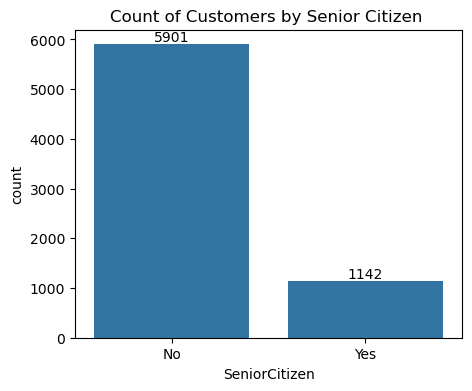

In [15]:
plt.figure(figsize = (5,4))
ax = sns.countplot(x="SeniorCitizen", data = df )
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senior Citizen ")
plt.show()

#### Comparative a greater percentage of people in senior citizen category have churned

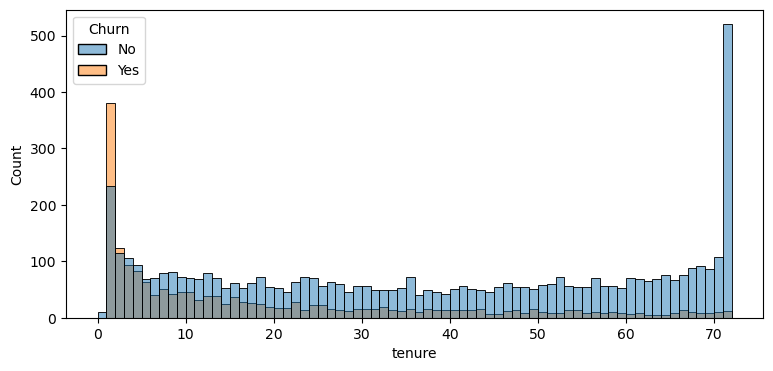

In [16]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue ="Churn")
plt.show()

#### People who have used our services for a long time have stayed and people who have used our services for  1 or 2 months have churned

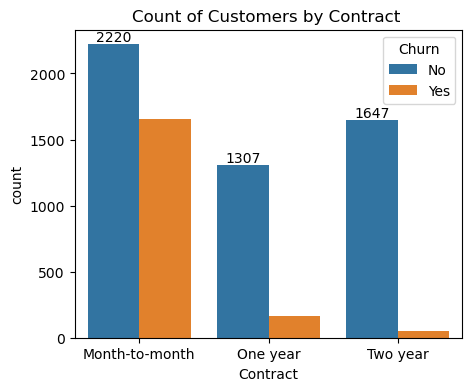

In [17]:
plt.figure(figsize = (5,4))
ax = sns.countplot(x="Contract", data = df, hue = "Churn" )
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract ")
plt.show()

#### People who have Month to Month Contract are likely to Churn then from those who have 1 or 2 years of Contracts 

In [18]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

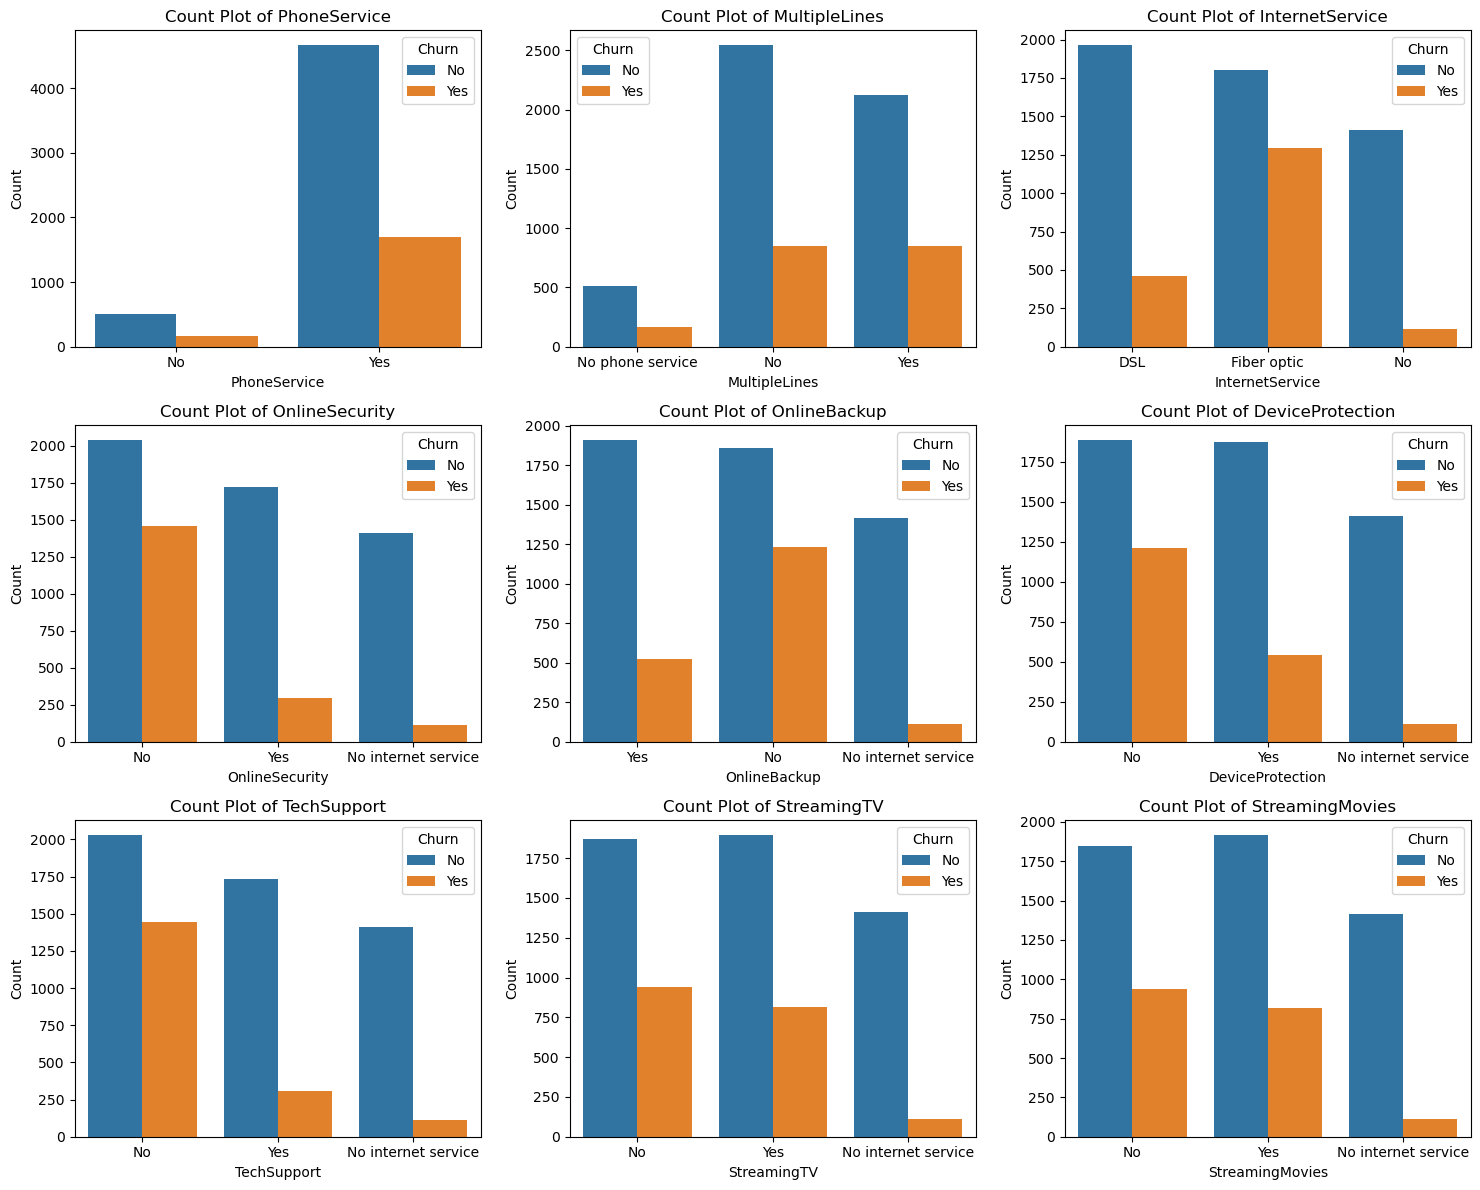

In [19]:
columns = ['PhoneService', 'MultipleLines', 'InternetService',
           'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
           'TechSupport', 'StreamingTV', 'StreamingMovies']

# Number of columns in grid
n_cols = 3

# Calculate rows automatically
n_rows = (len(columns) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))

# Flatten axes
axes = axes.flatten()

# Loop and plot
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**1. Most customers without OnlineSecurity, TechSupport have high churn.**  
**2. Fiber optic users have higher churn than DSL users.**  
**3. Customers using more services tend to stay longer.**  
**4. Lack of services increases churn rate.**  

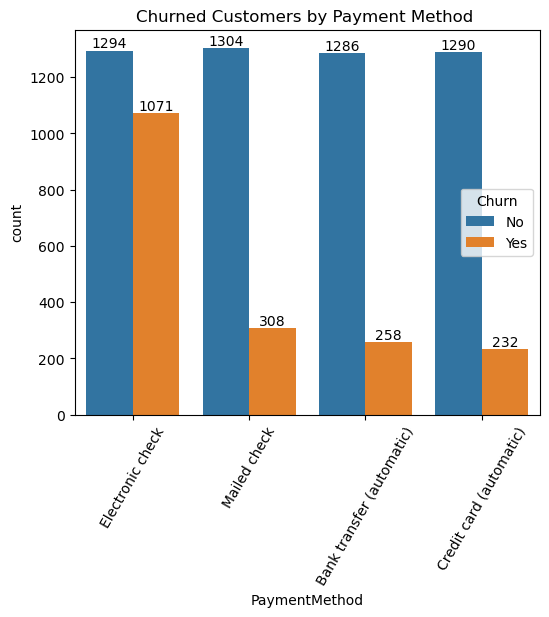

In [21]:

plt.figure(figsize = (6,5))
ax = sns.countplot(x="PaymentMethod", data = df, hue = "Churn" )
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method ")
plt.xticks(rotation = 60)
plt.show()

#### Customer is likely to churn when he is using electronic check as a payment method.